<a href="https://colab.research.google.com/github/whoisndu/Harvard-MATH-142-Assignments/blob/main/tutorial_gmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Mixture Models
Createdby Marc Deisenroth

Edited by Kris Lokere

In this notebook, we will look at density modeling with Gaussian mixture models (GMMs).
In Gaussian mixture models, we describe the density of the data as
$$
p(\boldsymbol x) = \sum_{k=1}^K \pi_k N(\boldsymbol x|\boldsymbol \mu_k, \boldsymbol \Sigma_k)\,,\quad \pi_k \geq 0\,,\quad \sum_{k=1}^K\pi_k = 1
$$

The goal of this notebook is to get a better understanding of GMMs and to write some code for training GMMs using the EM algorithm. We provide a code skeleton and mark the bits and pieces that you need to implement yourself.

In [ ]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from scipy.stats import multivariate_normal

np.random.seed(42)

### Define a GMM from which we generate data
Set up the true GMM from which we will generate data.

In [ ]:
# Choose a GMM with 3 components

# means
m = np.zeros((3,2))
m[0] = np.array([1.2, 0.4])
m[1] = np.array([-4.4, 1.0])
m[2] = np.array([4.1, -0.3])

# covariances
S = np.zeros((3,2,2))
S[0] = np.array([[0.8, -0.4], [-0.4, 1.0]])
S[1] = np.array([[1.2, -0.8], [-0.8, 1.0]])
S[2] = np.array([[1.2, 0.6], [0.6, 3.0]])

# mixture weights
w = np.array([0.3, 0.2, 0.5])

Generate some data

In [ ]:
N_split = 200 # number of data points per mixture component
N = N_split*3 # total number of data points
x = []
y = []
for k in range(3):
    x_tmp, y_tmp = np.random.multivariate_normal(m[k], S[k], N_split).T
    x = np.hstack([x, x_tmp])
    y = np.hstack([y, y_tmp])

data = np.vstack([x, y])

In [ ]:
# how many samples did we create?
# are the samples stored as rows or as columns?
print(data.shape)
print("Number of samples:", data.shape[1])
print("Samples are stored as columns.")

(2, 600)
Number of samples: 600
Samples are stored as columns.


Visualization of the dataset

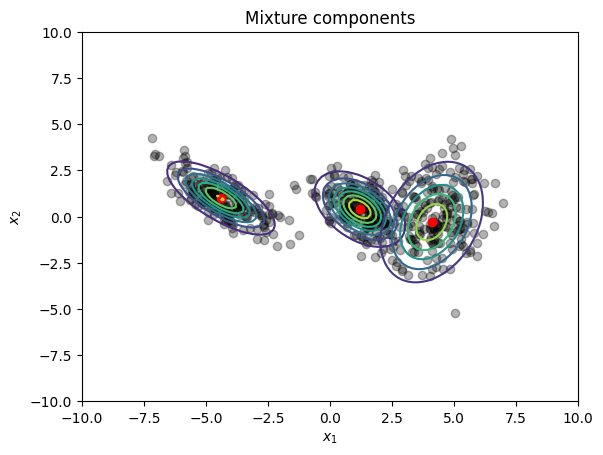

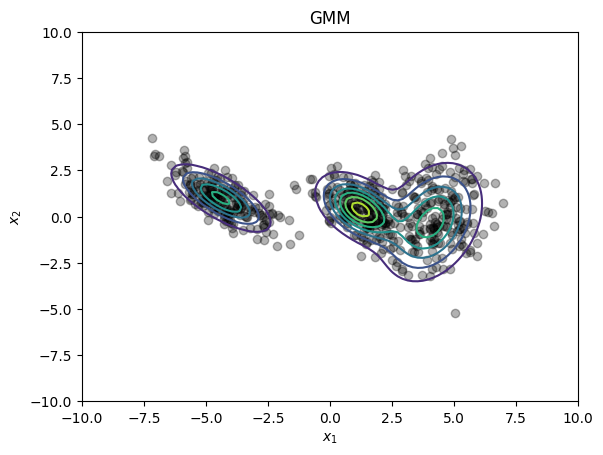

In [ ]:
X, Y = np.meshgrid(np.linspace(-10,10,100), np.linspace(-10,10,100))
pos = np.dstack((X, Y))

# plot the dataset
plt.figure()
plt.title("Mixture components")
plt.plot(x, y, 'ko', alpha=0.3)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# plot the means of the individual components
plt.plot(m[:,0], m[:,1], 'or')

# plot countour lines of the individual components
for k in range(3):
    mix_comp = multivariate_normal(m[k,:].ravel(), S[k,:,:]) # from scipy.stats, to get actual pdf functions
    plt.contour(X, Y, mix_comp.pdf(pos),  alpha = 1.0, zorder=10)

# second plot:

# plot the dataset
plt.figure()
plt.title("GMM")
plt.plot(x, y, 'ko', alpha=0.3)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# build the combined distribution
gmm = 0
for k in range(3):
    mix_comp = multivariate_normal(m[k,:].ravel(), S[k,:,:])
    gmm += w[k]*mix_comp.pdf(pos)

# plot countour lines of the combined distribution
plt.contour(X, Y, gmm,  alpha = 1.0, zorder=10);

## Train the GMM via EM
### Initialize the parameters for EM

In [ ]:
K = 3 # number of clusters

means = np.zeros((K,2))
covs = np.zeros((K,2,2))
for k in range(K):
    means[k] = np.random.normal(size=(2,)) # randomly initialize the means
    covs[k] = np.eye(2) # initialize the covariance as identity matrix

weights = np.ones((K,))/K # initialize the weights as all equal and adding up to 1
print("Initial mean vectors (one per row):\n" + str(means))

Initial mean vectors (one per row):
[[ 0.1252245  -0.42940554]
 [ 0.1222975   0.54329803]
 [ 0.04886007  0.04059169]]


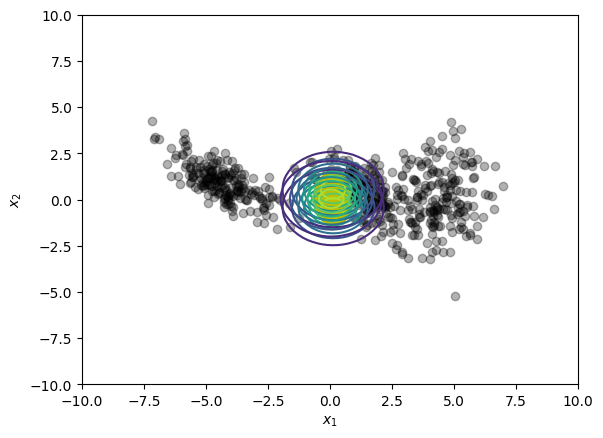

In [ ]:
# plot the data with the initial distributions
plt.figure()
plt.plot(x, y, 'ko', alpha=0.3)
plt.plot(means[:,0], means[:,1], 'oy', markersize=25)

for k in range(K):
    rv = multivariate_normal(means[k], covs[k])
    plt.contour(X, Y, rv.pdf(pos), alpha = 1.0, zorder=10)

plt.xlabel("$x_1$");
plt.ylabel("$x_2$");

Calculate the (negative) log likelihood $-\log p(X|\theta)$ for all the samples $x_n$ in the data, using the current values of the parameters (means, covariances, weights). See formula (11.10)

In [ ]:
# EDIT THIS FUNCTION
def neg_log_likelihood(data, means, covs, weights):
    N = data.shape[1]
    K = means.shape[0]
    nll = 0
    for n in range(N):
      likelihood = 0
      for k in range(K):
        likelihood += weights[k]*multivariate_normal.pdf(mean=means[k], cov=covs[k], x=data[:,n])
      nll -= np.log(likelihood) # <-- REPLACE THIS LINE
    return nll

In [ ]:
# what is the initial NLL before any iterations?
neg_log_likelihood(data, means, covs, weights)

np.float64(5762.109091292175)

## Build the EM Model

First, we define the responsibilities (which are updated in the E-step), given the model parameters $\pi_k, \boldsymbol\mu_k, \boldsymbol\Sigma_k$ as
$$r_{nk} := \frac{\pi_k \;N(\boldsymbol x_n|\boldsymbol\mu_k,\boldsymbol\Sigma_k)}{\sum_{j=1}^K\pi_j\; N(\boldsymbol x_n|\boldsymbol \mu_j,\boldsymbol\Sigma_j)}$$

Given the responsibilities we just defined, we can update the model parameters in the M-step as follows:
\begin{align*}
\boldsymbol\mu_k^\text{new} &= \frac{1}{N_k}\sum_{n = 1}^Nr_{nk}\boldsymbol x_n\,,\\
   \boldsymbol\Sigma_k^\text{new}&= \frac{1}{N_k}\sum_{n=1}^Nr_{nk}(\boldsymbol x_n-\boldsymbol\mu_k)(\boldsymbol x_n-\boldsymbol\mu_k)^\top\,,\\
   \pi_k^\text{new} &= \frac{N_k}{N}
\end{align*}
where $$
N_k := \sum_{n=1}^N r_{nk}
$$

### EM Algorithm

Converged after iteration  99


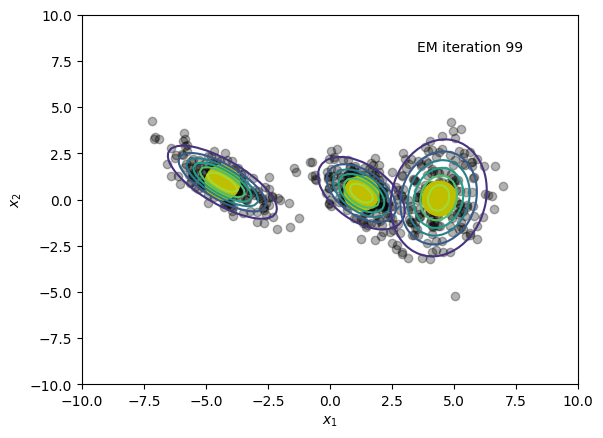

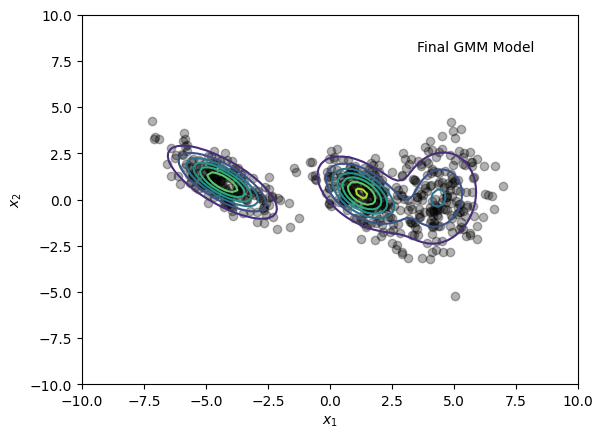

In [ ]:
#EDIT THIS FUNCTION
r = np.zeros((K,N)) # will store the responsibilities

NLL = [] # list to store the neg-log-likelihoods of each iteration
NLL += [neg_log_likelihood(data, means, covs, weights)] # append the initial value to the list

fig = plt.figure()

for em_iter in range(100):    # run 100 steps (iterations) of EM

    # E-step: update responsibilities
    for k in range(K):
        r[k] = weights[k]*multivariate_normal.pdf(mean=means[k,:], cov=covs[k,:,:], x=data.T)
    r = r/np.sum(r, axis=0)

    # M-step
    N_k = np.sum(r, axis=1)

    for k in range(K):
        # update the means
        means[k] = np.sum(r[k] * data, axis=1) / N_k[k]# <-- EDIT THIS LINE

        # update the covariances
        diff = data - means[k].reshape(-1,1) # x - mu
        for n in range(N):
            covs[k] += r[k, n] * np.outer(diff[:, n], diff[:, n])# <-- EDIT THIS LINE
        covs[k] = covs[k]/N_k[k]

    # weights
    weights = N_k / N #<-- EDIT THIS LINE

    # calculate new neg-log-likelihood and append to the list
    NLL += [neg_log_likelihood(data, means, covs, weights)]

    fig.clear()
    plt.plot(x, y, 'ko', alpha=0.3)
    plt.plot(means[:,0], means[:,1], 'oy', markersize=25)
    for k in range(K):
        rv = multivariate_normal(means[k], covs[k])
        plt.contour(X, Y, rv.pdf(pos), alpha = 1.0, zorder=10)

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.text(x=3.5, y=8, s="EM iteration "+str(em_iter+1))

    display.display(fig)
    display.clear_output(wait=True)

    if np.linalg.norm(NLL[em_iter+1]-NLL[em_iter]) < 1e-6:
        print("Converged after iteration ", em_iter+1)
        break

# plot final the mixture model
plt.figure()
gmm = 0
for k in range(3):
    mix_comp = multivariate_normal(means[k], covs[k])
    gmm += weights[k]*mix_comp.pdf(pos)

plt.plot(x, y, 'ko', alpha=0.3)
plt.contour(X, Y, gmm,  alpha = 1.0, zorder=10)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.text(x=3.5, y=8, s="Final GMM Model ")
plt.show()

Finally, make a plot of how the negative log likelihood evolves as we go through our iterations

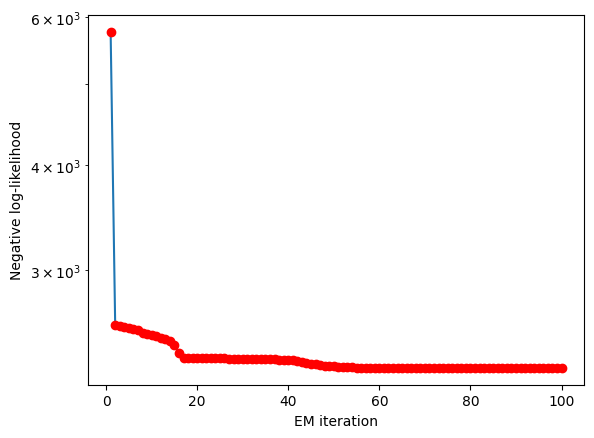

In [ ]:
plt.figure()
plt.semilogy(np.linspace(1,len(NLL), len(NLL)), NLL)
plt.xlabel("EM iteration");
plt.ylabel("Negative log-likelihood");

for i in range(len(NLL)):
    plt.plot(i+1, NLL[i], 'or')